### 0. Import packages

In [1]:
import logomaker
import glob as glob
import sys, os

os.path.dirname(sys.executable)

import pandas as pd
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt

import sys, os, json, textwrap, itertools, requests
from pathlib import Path

from Bio.PDB import PDBParser, NeighborSearch, is_aa
from Bio.Data.IUPACData import protein_letters_3to1

import re
from typing import Optional          

from Bio.PDB import PDBParser, NeighborSearch
from scipy.spatial.distance import cdist

### 1. Exploration of structure-derived peptides

In [2]:
def aggregate_results(results_files, run_id_level=-2, extra_columns=None):
    """
    Aggregate CSV files into a single DataFrame with run identifiers.
    
    Args:
        results_files (list): List of paths to CSV files.
        run_id_level (int): Directory level to extract run ID (e.g., -2 for parent of filename).
        extra_columns (dict): Optional dictionary of column_name: lambda_function to add metadata.
    
    Returns:
        pd.DataFrame: Concatenated DataFrame with run IDs and optional columns.
    """
    if not results_files:
        print("Warning: No files provided.")
        return pd.DataFrame()

    dfs = []
    for file_path in results_files:
        # try:
        # Read CSV
        tmp = pd.read_csv(file_path)
        
        # Extract run ID from path
        run_id = os.path.split(os.path.dirname(file_path))[run_id_level]
        tmp['RUN'] = run_id
        
        # Add optional columns
        # if extra_columns:
        #     for col_name, func in extra_columns.items():
        #         tmp[col_name] = func(file_path)
        
        dfs.append(tmp)
        # print(f"Processed: {file_path}")

    # Concatenate all DataFrames
    if dfs:
        results = pd.concat(dfs, axis=0 )# , ignore_index=True)
        print(f"Aggregated {len(dfs)} files into DataFrame with {len(results)} rows.")
        return results
    else:
        print("No valid files processed.")
        return pd.DataFrame()

def grab_hla(title: str) -> Optional[str]:   # <- use Optional[str] instead of str | None
    """
    Return the first HLA allele in *title* or None.
    Handles:  HLA-A*02:01,  HLA-A02:01,  HLA-A*0201,  HLA-A0201
    """
    patterns = [
        r'(HLA-[A-Z]\*\d{2}:\d{2})',   # HLA-A*02:01
        r'(HLA-[A-Z]\d{2}:\d{2})',     # HLA-A02:01
        r'([A-Z]\*\d{4})',         # HLA-A*0201
        r'(-[A-Z]\*\d{2}:\d{2})'  ,
        r'([A-Z]\d{2}\d{2})'  ,
        r'([A-Z]\*\d{2}:\d{2})' ,
        r'(-[A-Z]\d{1}:\d{2})'  ,
        r'(-[A-Z]\d{1})'   ,
        r'(-[A-Z]\d{2})'            # HLA-A0201
    ]
    for p in patterns:
        m = re.search(p, title, flags=re.IGNORECASE)
        if m:
            return m.group(1).upper()
    return None

# Example usage for RFdiffusion results
results_dir = "/clusterfs/nilah/sergio/RFdifussion/outputs/"
results_files = glob.glob(f'{results_dir}/*/*/*.csv')

# # Define extra columns (e.g., extract contigs, iterations, num_seqs from run name)
# extra_columns = {
#     'contigs': lambda x: x.split('/')[-3].split('_C')[1].split('_I')[0],
#     'iterations': lambda x: x.split('_I')[1].split('_NS')[0],
#     'num_seqs': lambda x: x.split('_NS')[1].split('_')[0]
# }

# # Aggregate results
results = aggregate_results(results_files, run_id_level=-2) #, extra_columns=extra_columns)

# results = pd.read_csv('../data/HLAA0201_PDB_7RTD_RFdiffusion_sequences.csv')
# results['epitope'] = results['seq'].apply(lambda x: x.split("/")[1])
results['length'] = results['seq'].apply(lambda x: len(x))
results = results[results['length'] < 15]
results = results.drop_duplicates('seq')
results['epitope'] = results['seq']

Aggregated 4572 files into DataFrame with 146304 rows.


In [3]:
results.to_csv('../data/negative_ctrl_library.csv', index = False)

<Axes: >

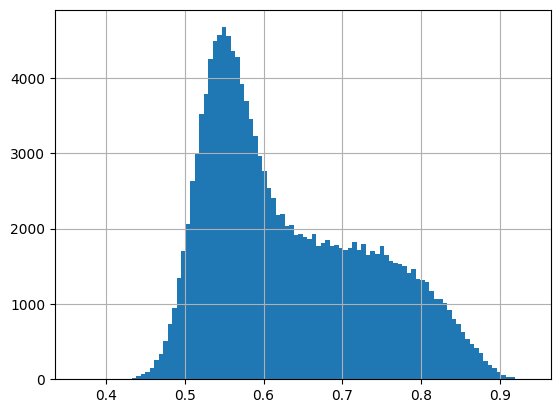

In [4]:
results['plddt'].hist(bins=100)

In [5]:
# results_meta = pd.merge(results_pdbs, df_meta, left_on='PDB', right_on='pdb_id', how='left')

results_meta = pd.read_csv('../data/rdfiffusion_output_peptides.csv.gz',compression='gzip')

results_meta['hla_allele'] = results_meta['title'].apply(grab_hla)
results_meta['hla_allele'] = results_meta['hla_allele'].str.replace('HLA','').str.replace('-','').str.replace(':','').str.replace('*','')
results_meta['epitope'] = results_meta['seq'].apply(lambda x: x.split("/")[1])
results_meta['length'] = results_meta['epitope'].apply(lambda x: len(x))
results_meta = results_meta.drop_duplicates(['pdb_id', 'epitope'])

In [6]:
AA = list("ACDEFGHIKLMNPQRSTVWY")
def build_pwm(df: pd.DataFrame,
              seq_col: str,
              allele_col: str,
              length: int = 9,
              pseudocount: int = 1):
    """
    Return {allele: (L, 20) numpy array} where rows = positions,
    columns = AA probabilities.
    Only sequences of exact 'length' are used.
    """
    pwm = {}
    for hla, grp in df[df[seq_col].str.len() == length].groupby(allele_col):
        counts = np.zeros((length, 20))
        for seq in grp[seq_col]:
            for i, aa in enumerate(seq):
                if aa in AA:
                    counts[i, AA.index(aa)] += 1
        counts += pseudocount
        pwm[hla] = counts / counts.sum(axis=1, keepdims=True)
    return pwm

In [7]:
results['hla_allele'] = 'A0201'

In [8]:
results_meta['hla_allele'].unique()

array(['B5301', 'B2705', 'B1502', None, 'N0101', 'B5703', 'B8', 'A0201',
       'B1801', 'B3501', 'A2402', 'B4403', 'B3508', 'B1301', 'A2',
       'B4405', 'B5801', 'B3505', 'B1501', 'A6', 'A0206', 'A0207',
       'B4001', 'B5803', 'B5701', 'C1203', 'C1202', 'B2706', 'B3503'],
      dtype=object)

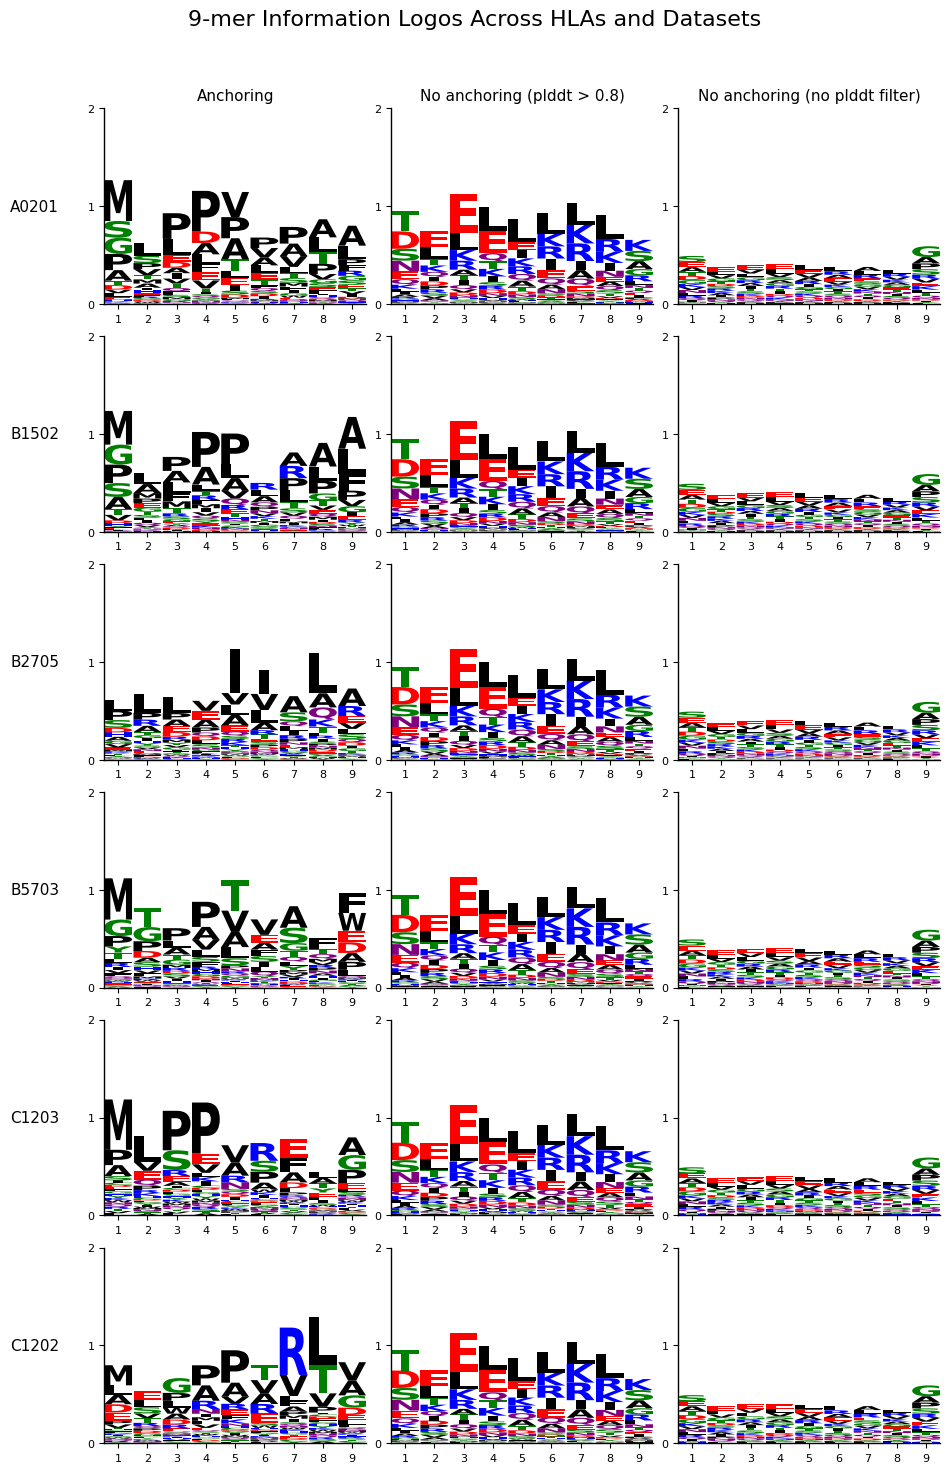

In [9]:

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
bg_probs = [1 / 20] * 20
alleles =  ['A0201','B1502', 'B2705', 'B5703', 'C1203', 'C1202'] #results_meta[results_meta['hla_allele'].notna()]['hla_allele'].unique()
datasets_names = ["Anchoring", "No anchoring (plddt > 0.8)", "No anchoring (no plddt filter)"]

n_rows = len(alleles)
n_cols = len(datasets_names)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 2.4), squeeze=False)

for row_idx, allele in enumerate(alleles):

    pwm_pred     = build_pwm(results_meta[(results_meta['plddt'] > 0.5) & (results_meta['hla_allele'] == allele)],
                            seq_col="epitope",  allele_col="hla_allele")
    
    results['hla_allele'] = allele

    pwm_train     = build_pwm(results[(results['plddt'] > 0.8)],
                        seq_col="seq",  allele_col="hla_allele")

    pwm_train2     = build_pwm(results,
                        seq_col="seq",  allele_col="hla_allele")

    datasets = {
        "Anchoring": pwm_pred,
        "No anchoring (plddt > 0.8)": pwm_train,
        "No anchoring (no plddt filter)": pwm_train2
    }

    common_hlas = sorted(set.intersection(*(set(d) for d in datasets.values())))
    if not common_hlas:
        continue

    hla = common_hlas[0]  # pick one if only one per allele anyway

    for col_idx, (dataset_name, pwm_dict) in enumerate(datasets.items()):
        ax = axes[row_idx][col_idx]
        pwm = pwm_dict[hla]
        freq_df = pd.DataFrame(pwm, columns=amino_acids)
        info_df = logomaker.transform_matrix(freq_df, from_type="probability", to_type="information", background=bg_probs)

        logo = logomaker.Logo(info_df, ax=ax, color_scheme="chemistry")
        logo.style_spines(visible=False)
        logo.style_spines(spines=['left', 'bottom'], visible=True)

        ax.set_xticks(range(pwm.shape[0]))
        ax.set_xticklabels([str(i + 1) for i in range(pwm.shape[0])], fontsize=8)
        ax.set_yticks([0, 1, 2])
        ax.set_yticklabels(["0", "1", "2"], fontsize=8)
        ax.set_ylabel("")

        if row_idx == 0:
            ax.set_title(dataset_name, fontsize=11, pad=6)
        if col_idx == 0:
            ax.set_ylabel(allele, rotation=0, fontsize=11, labelpad=38, va="center")

plt.suptitle("9-mer Information Logos Across HLAs and Datasets", fontsize=16, y=1.02)
plt.tight_layout(h_pad=0.6, w_pad=0.6)

In [58]:
from scipy.stats import gaussian_kde
from matplotlib.patches import Rectangle
from matplotlib.ticker import PercentFormatter
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_kde_density(
    df,
    pos2_set={"M", "L", "T"},
    last_set={"V", "L", "T", "A"},
    alleles=('A0201', 'A0206', 'A0207'),
    match_types=("pos2_match", "last_match", "either_match", "both_match"),
    x_candidates=("rmsd", "i_ptm", "_iptm", "mpnn"),
    y_col="plddt",
    show_grey=True,
    show_window=True,
    thr=0.80,
    save_dir="../figures",
    fname_prefix="kde_density",
    # -------- new controls --------
    figure_title=None,            # override the auto suptitle if provided
    suptitle_size=18,             # size of the main title (suptitle)
    panel_title_size=13,          # size of per-panel titles
    axis_label_size=12,           # size of x/y axis labels
    tick_label_size=10,           # size of tick labels
    legend_size=10,               # size of legend and colorbar label
    annotation_size=10            # size of in-plot annotations
):
    """
    KDE density scatter for peptide quality vs confidence, split by anchor-match logic.

    Returns:
        pandas.DataFrame with per-panel counts (N_in window, totals, fractions).
    """

    # ---------- style: journal-ready ----------
    mpl.rcParams.update({
        "figure.dpi": 180,
        "savefig.dpi": 300,
        "axes.titlesize": panel_title_size,
        "axes.labelsize": axis_label_size,
        "xtick.labelsize": tick_label_size,
        "ytick.labelsize": tick_label_size,
        "legend.fontsize": legend_size,
        "font.family": "DejaVu Sans",
    })
    sns.set_theme(context="paper", style="white")  

    # ---------- nice labels for columns ----------
    label_map = {
        "rmsd": "Backbone RMSD (Å)",
        "i_ptm": "Interface pTM score",
        "_iptm": "Interface pTM score",
        "mpnn": "ProteinMPNN sequence score",
        "plddt": "AlphaFold pLDDT",
    }

    # pick the first available x column
    x_col = next((c for c in x_candidates if c in df.columns), None)
    if x_col is None:
        raise ValueError(f"No x-column found. Tried: {x_candidates}")

    # enforce required columns
    needed = {x_col, y_col, "epitope", "hla_allele"}
    missing = sorted(list(needed - set(df.columns)))
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # subset to alleles if provided
    sub = df[[x_col, y_col, "epitope", "hla_allele"]].copy()
    if alleles is not None:
        sub = sub[sub["hla_allele"].isin(alleles)]
    sub = sub.dropna()

    # class annotations
    s = sub["epitope"].astype(str).str.upper()
    sub["pos2_match"]   = s.str.len().ge(2) & s.str[1].isin(pos2_set)
    sub["last_match"]   = s.str.len().ge(1) & s.str[-1].isin(last_set)
    sub["either_match"] = sub["pos2_match"] | sub["last_match"]
    sub["both_match"]   = sub["pos2_match"] & sub["last_match"]

    valid_matches = {"pos2_match", "last_match", "either_match", "both_match"}
    match_types = [m for m in match_types if m in valid_matches]
    if not match_types:
        raise ValueError(f"No valid match types provided. Valid options: {sorted(valid_matches)}")

    # helper: KDE density
    def point_density(x, y):
        x = np.asarray(x, float)
        y = np.asarray(y, float)
        if len(x) < 5:
            return np.zeros_like(x)
        kde = gaussian_kde(np.vstack([x, y]))
        return kde(np.vstack([x, y]))

    # helper: annotate high-confidence quadrant
    def annotate_window(ax, data, x_col, y_col, thr):
        if not show_window:
            return None, len(data), None

        ax.axvline(thr, ls="--", lw=1, color="gray", alpha=0.9, zorder=1)
        ax.axhline(thr, ls="--", lw=1, color="gray", alpha=0.9, zorder=1)
        ax.add_patch(Rectangle((thr, thr), 1 - thr, 1 - thr,
                               facecolor="gray", alpha=0.08, zorder=0))
        ax.text(thr + 0.01, thr + 0.01, "High-confidence quadrant",
                fontsize=annotation_size, color="gray", va="bottom", ha="left")

        n_total = len(data)
        mask_in = (data[x_col] >= thr) & (data[y_col] >= thr)
        n_in = int(mask_in.sum())
        frac = n_in / n_total if n_total else np.nan

        ax.text(0.01, 0.99,
                f"N in quadrant (≥{thr}, ≥{thr}) = {n_in:,}/{n_total:,} ({frac:.1%})",
                transform=ax.transAxes, ha="left", va="top",
                fontsize=annotation_size,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", alpha=0.95))
        return n_in, n_total, frac

    # panel title helpers
    panel_title = {
        "pos2_match":   "Position 2 anchor match",
        "last_match":   "C-terminus anchor match",
        "either_match": "Either anchor match",
        "both_match":   "Both anchors match",
    }
    side_title = {False: "No", True: "Both"}

    # set sensible axis ranges if scores are on [0,1]
    def score_bounds(col, name):
        if col in ("plddt", "i_ptm", "_iptm", "mpnn"):
            return (0.0, 1.0)
        if name == label_map.get("rmsd", "") or col == "rmsd":
            return None
        return None

    # collect counts
    all_counts = []

    for group_col in match_types:
        g_false = sub[sub[group_col] == False].copy()
        g_true  = sub[sub[group_col] == True].copy()

        g_false["density"] = point_density(g_false[x_col], g_false[y_col])
        g_true["density"]  = point_density(g_true[x_col], g_true[y_col])

        # shared color scale per figure
        all_d = np.concatenate([g_false["density"].values, g_true["density"].values]) \
                if (len(g_false) + len(g_true)) else np.array([0.0])
        vmin = float(np.min(all_d))
        vmax = float(np.percentile(all_d, 99)) if np.isfinite(all_d).any() else 1.0

        # -------- CHANGED: make a 2x1 stacked layout --------
        fig, axes = plt.subplots(2, 1, figsize=(8.0, 10.0), sharex=True, sharey=True)

        allele_str = ", ".join(alleles) if alleles else "All alleles"
        anchor_note = f"P2 Anchors: {sorted(pos2_set)} | PΩ anchors: {sorted(last_set)}"
        auto_title = (
            f"{allele_str}  {label_map.get(x_col, x_col)} vs {label_map.get(y_col, y_col)}\n"
            f"{anchor_note}"
        )
        # fig.suptitle(figure_title if figure_title is not None else auto_title,
        #                 y=0.995, fontsize=suptitle_size)
        plt.grid(False)
        # top = No, bottom = Both
        for ax, d, side in ((axes[0], g_false, False), (axes[1], g_true, True)):

            if show_grey and len(sub):
                sns.scatterplot(
                    data=sub, x=x_col, y=y_col,
                    color="0.65", s=6, linewidth=0, alpha=0.25, ax=ax, legend=False
                )

            p = sns.scatterplot(
                data=d, x=x_col, y=y_col, hue="density",
                palette="viridis", hue_norm=(vmin, vmax),
                s=10, linewidth=0, alpha=0.9, ax=ax, legend=False
            )

            ax.set_title(f"{side_title[side]} Anchor Match", pad=6, fontsize=panel_title_size)
            ax.set_xlabel(label_map.get(x_col, x_col), fontsize=axis_label_size)
            ax.set_ylabel(label_map.get(y_col, y_col), fontsize=axis_label_size)
            ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

            ax.grid(False)
            xb = score_bounds(x_col, label_map.get(x_col, ""))
            yb = score_bounds(y_col, label_map.get(y_col, ""))
            if xb is not None:
                ax.set_xlim(*xb)
            if yb is not None:
                ax.set_ylim(*yb)

            n_in, n_total, frac = annotate_window(ax, d, x_col, y_col, thr)
            all_counts.append({
                "alleles": allele_str,
                "group": group_col,
                "match_side": side_title[side],
                "x": x_col,
                "y": y_col,
                "threshold": thr,
                "N_in_quadrant": n_in,
                "N_total": n_total,
                "frac_in_quadrant": frac
            })

            if len(d):
                norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
                sm = mpl.cm.ScalarMappable(cmap="viridis", norm=norm)
                sm.set_array([])
                cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.01)
                cbar.set_label("Point density (KDE)", size=legend_size)
                cbar.ax.tick_params(labelsize=tick_label_size)

            plt.grid(False)

        if show_window:
            fig.text(
                0.01, 0.005,
                f"Shaded region marks high-confidence quadrant (≥{thr} on both axes). "
                f"Background points show all peptides for context.",
                fontsize=annotation_size
            )

        from scipy.stats import mannwhitneyu, ks_2samp

        # add inside the loop for each match type
        tests = []
        for col in [x_col, y_col]:
            label = label_map.get(col, col)
            a = g_false[col].values
            b = g_true[col].values

            if len(a) >= 2 and len(b) >= 2:
                u = mannwhitneyu(a, b, alternative="two-sided")
                ks = ks_2samp(a, b, alternative="two-sided", mode="auto")
                delta = cliffs_delta(a, b)
                tests.append({
                    "group": group_col,
                    "variable": col,
                    "label": label,
                    "n_false": len(a), "n_true": len(b),
                    "mw_U": u.statistic, "mw_p": u.pvalue,
                    "ks_D": ks.statistic, "ks_p": ks.pvalue,
                    "cliffs_delta": delta
                })

        fig.tight_layout(rect=[0, 0.02, 1, 0.975])  # leave room for suptitle and footer

        safe_group = group_col.replace(" ", "_")
        safe_x = x_col.replace("/", "_")
        safe_y = y_col.replace("/", "_")
        safe_alleles = "_".join(a.replace("*", "").replace(":", "") for a in alleles) if alleles else "ALL"
        base = f"{save_dir}/{fname_prefix}__{safe_alleles}__{safe_group}__{safe_x}_vs_{safe_y}"
        # plt.grid(False)
        # plt.savefig(base + ".png", bbox_inches="tight")
        plt.savefig(base + ".pdf", bbox_inches="tight")
        plt.show()

    return pd.DataFrame(all_counts)

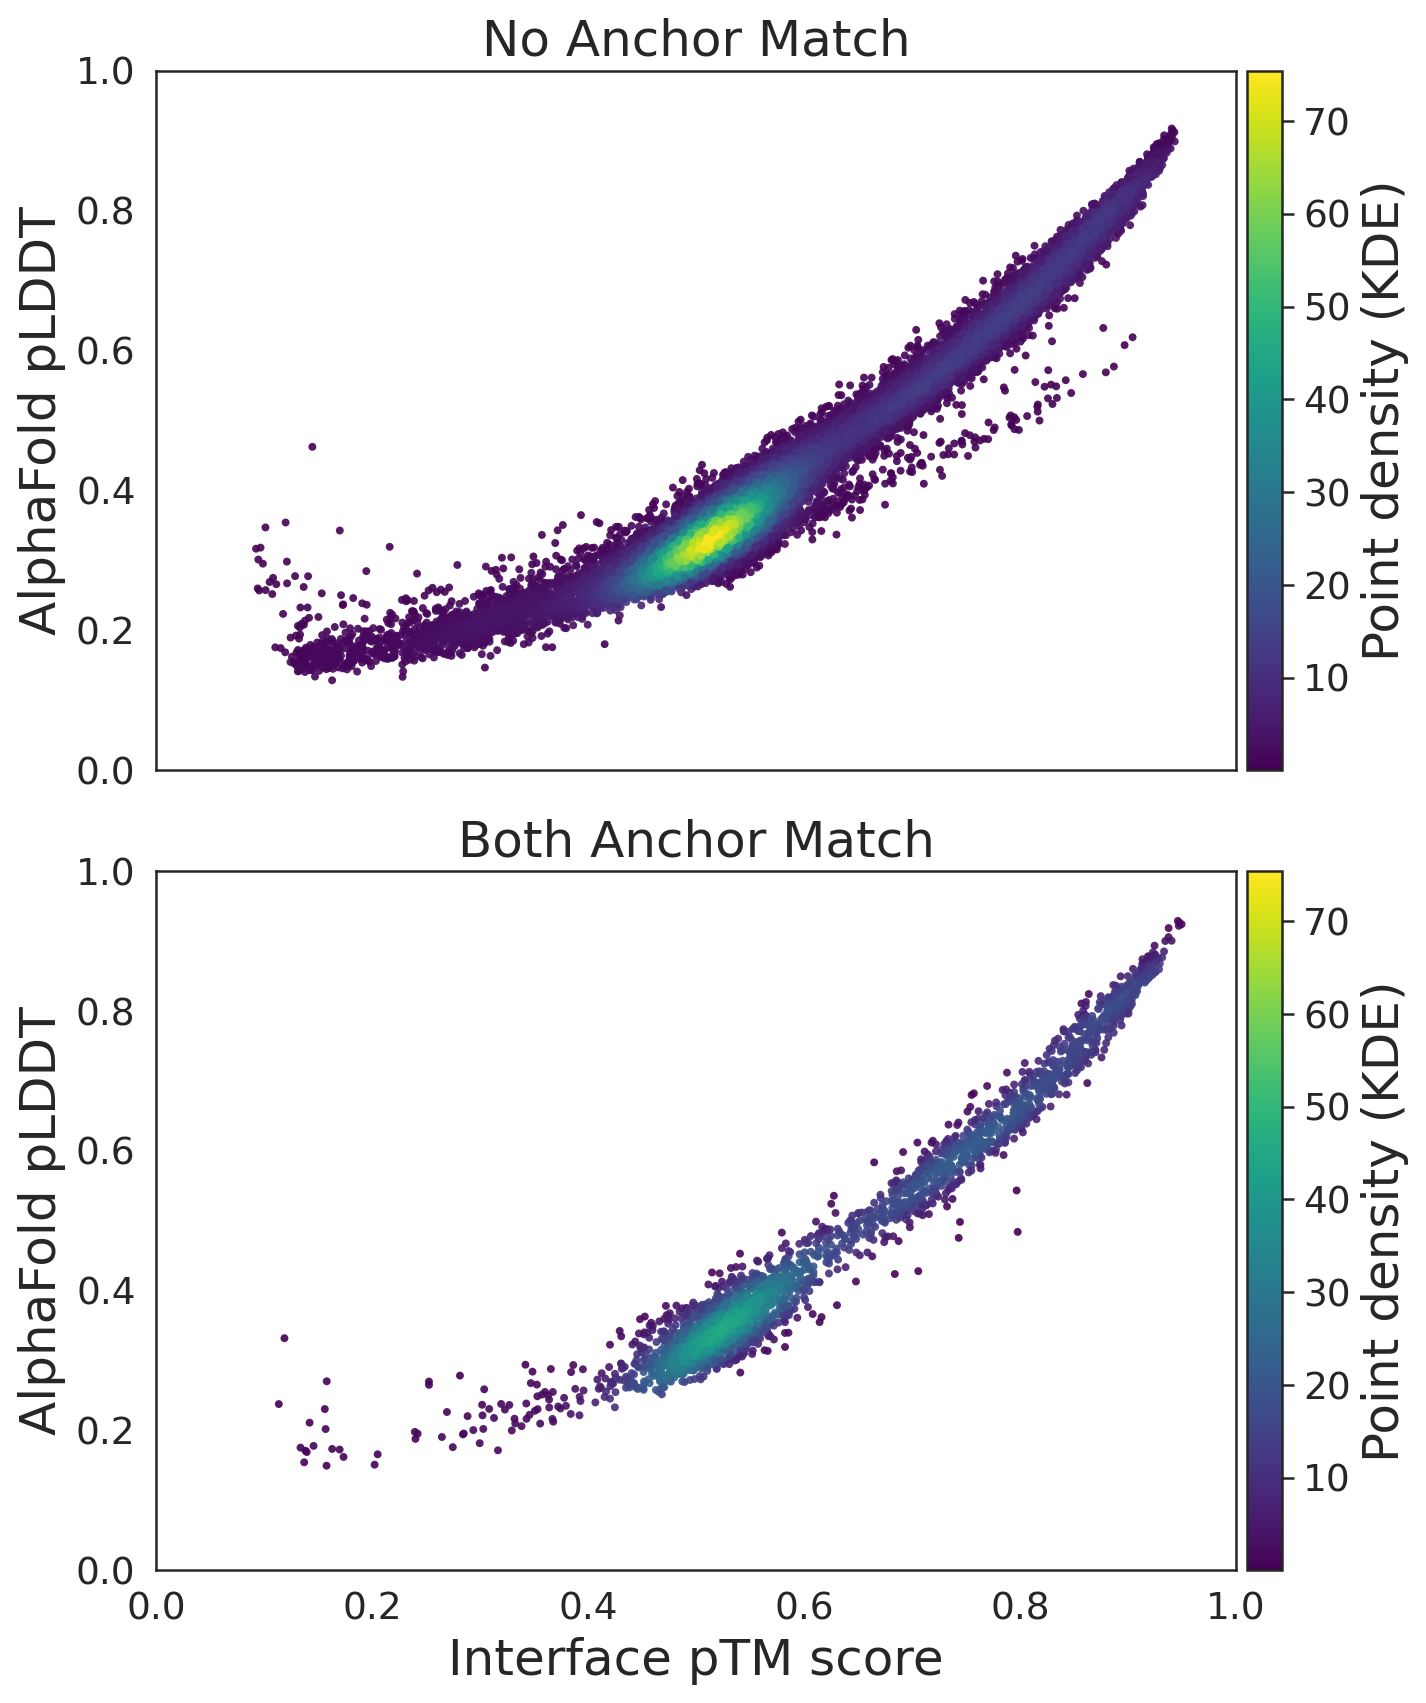

In [69]:
counts = plot_kde_density(
    results_meta,
    pos2_set={"M", "L", "T"},
    last_set={"V", "L", "T", "A"},
    x_candidates = ['i_ptm'],
    alleles=['A0201', 'A0206', 'A0207'],
    match_types=["both_match"], #both_match last_match either_match pos2_match
    show_grey=False,
    show_window=False,
    thr=0.8,
    suptitle_size=25,
    panel_title_size=20,
    axis_label_size=20,
    tick_label_size=15,
    legend_size=20,
    annotation_size=20
)

,group,n_false,n_true,median_false,median_true,U,p_two_sided,delta_cliff
0,pos2_match,19190,5664,0.529026,0.550708,46123272.0,2.781314e-67,-0.151305
1,last_match,14389,10465,0.525524,0.543102,64937838.5,1.031210e-76,-0.137502
2,either_match,11151,13703,0.522245,0.542304,64104587.0,6.598515e-106,-0.160947
3,both_match,22428,2426,0.530308,0.568029,20926241.5,4.616249e-78,-0.230799


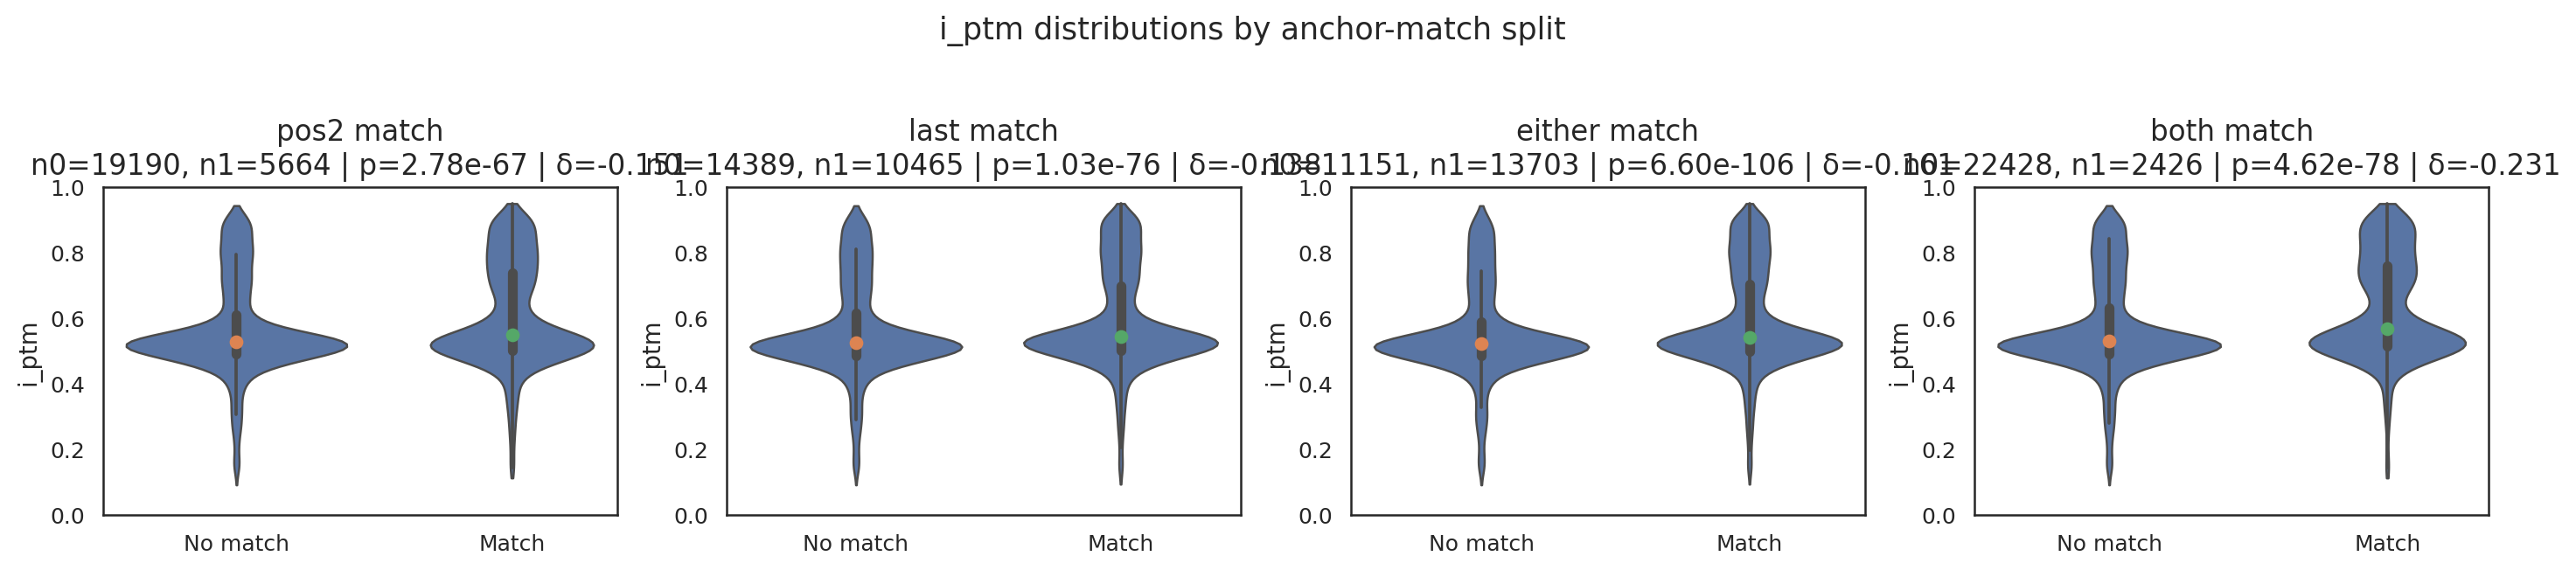

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

def plot_iptm_distributions_by_match(
    df,
    pos2_set={"M","L","T"},
    last_set={"V","L","T","A"},
    alleles=('A0201','A0206','A0207'),
    match_types=("pos2_match","last_match","either_match","both_match"),
    kind="violin",          # "violin" or "hist"
    bins=30,
    figsize=(14, 3.2),
    ylim=(0, 1.0),
    title="i_ptm distributions by anchor-match split",
    tick_fs=10, label_fs=11, title_fs=13, ann_fs=10
):
    # pick i_ptm column
    iptm_col = "i_ptm" if "i_ptm" in df.columns else "_iptm" if "_iptm" in df.columns else None
    if iptm_col is None:
        raise ValueError("No i_ptm column found. Looked for 'i_ptm' and '_iptm'.")

    # subset
    need = {iptm_col, "epitope", "hla_allele"}
    miss = list(need - set(df.columns))
    if miss:
        raise ValueError(f"Missing columns: {miss}")

    sub = df[list(need)].copy().dropna()
    if alleles is not None:
        sub = sub[sub["hla_allele"].isin(alleles)]

    # annotate match flags
    s = sub["epitope"].astype(str).str.upper()
    sub["pos2_match"]   = s.str.len().ge(2) & s.str[1].isin(pos2_set)
    sub["last_match"]   = s.str.len().ge(1) & s.str[-1].isin(last_set)
    sub["either_match"] = sub["pos2_match"] | sub["last_match"]
    sub["both_match"]   = sub["pos2_match"] & sub["last_match"]

    # layout
    mtypes = [m for m in match_types if m in {"pos2_match","last_match","either_match","both_match"}]
    if not mtypes:
        raise ValueError("No valid match_types.")
    fig, axes = plt.subplots(1, len(mtypes), figsize=(figsize[0], figsize[1]))
    if len(mtypes) == 1:
        axes = [axes]

    results = []
    for ax, grp in zip(axes, mtypes):
        a = sub.loc[sub[grp] == False, iptm_col].astype(float).to_numpy()
        b = sub.loc[sub[grp] == True,  iptm_col].astype(float).to_numpy()

        # prepare plotting df
        plot_df = pd.DataFrame({
            "i_ptm": np.concatenate([a, b]),
            "Match": np.array(["No match"] * len(a) + ["Match"] * len(b))
        })

        # draw
        if kind == "violin":
            sns.violinplot(data=plot_df, x="Match", y="i_ptm",
                           inner="box", cut=0, linewidth=1, ax=ax)
        elif kind == "hist":
            # side by side histograms
            ax.hist(a, bins=bins, alpha=0.6, label="No match", density=True)
            ax.hist(b, bins=bins, alpha=0.6, label="Match", density=True)
            ax.legend(fontsize=tick_fs)
            ax.set_xticks([])
        else:
            raise ValueError("kind must be 'violin' or 'hist'.")

        # stats
        if len(a) >= 2 and len(b) >= 2:
            res = mannwhitneyu(a, b, alternative="two-sided", method="auto")
            U = float(res.statistic)
            p = float(res.pvalue)
            delta = 2.0 * U / (len(a) * len(b)) - 1.0
        else:
            U, p, delta = np.nan, np.nan, np.nan

        # cosmetics
        ax.set_xlabel("")
        ax.set_ylabel("i_ptm", fontsize=label_fs)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.tick_params(labelsize=tick_fs)

        # panel title with n and stats
        ax.set_title(
            f"{grp.replace('_',' ')}\n"
            f"n0={len(a)}, n1={len(b)} | p={p:.2e} | δ={delta:.3f}",
            fontsize=title_fs
        )

        # mark medians
        med = plot_df.groupby("Match")["i_ptm"].median()
        for xpos, lab in enumerate(["No match","Match"]):
            if lab in med.index:
                ax.scatter([xpos], [med.loc[lab]], s=30, zorder=3)

        results.append({
            "group": grp,
            "n_false": len(a), "n_true": len(b),
            "median_false": float(np.median(a)) if len(a) else np.nan,
            "median_true":  float(np.median(b)) if len(b) else np.nan,
            "U": U, "p_two_sided": p, "delta_cliff": delta
        })

    fig.suptitle(title, fontsize=title_fs+1, y=1.05)
    fig.tight_layout()
    return pd.DataFrame(results)

# Example call:
dist_stats = plot_iptm_distributions_by_match(
    results_meta,
    pos2_set={"M","L","T"},
    last_set={"V","L","T","A"},
    alleles=('A0201','A0206','A0207'),
    match_types=("pos2_match","last_match","either_match","both_match"),
    kind="violin",   # or "hist"
    bins=30,
    figsize=(16, 3.4),
    ylim=(0, 1.0),
    title="i_ptm distributions by anchor-match split",
    tick_fs=10, label_fs=11, title_fs=13, ann_fs=10
)
dist_stats


Anchoring allele sizes:
 hla_allele
A0201    935
A2402    603
B1502    296
A0206     99
A0207     69
B2705     62
B5703     46
B5701     28
C1203     25
C1202     23 

Global most-uniform AAs (potential design bias), top 5:
    mean_across_alleles  var_across_alleles  cv_across_alleles
aa                                                            
C              0.000037        1.358127e-08           3.162278
K              0.006998        2.365886e-05           0.695060
N              0.011401        3.138311e-05           0.491363
H              0.008763        3.195512e-05           0.645061
D              0.027841        1.495946e-04           0.439315 

Per-position most-uniform AA positions (top 10):
    aa  pos  mean_across_alleles  var_across_alleles  cv_across_alleles
17   C    9             0.000000        0.000000e+00                NaN
16   C    8             0.000000        0.000000e+00                NaN
15   C    7             0.000000        0.000000e+00                

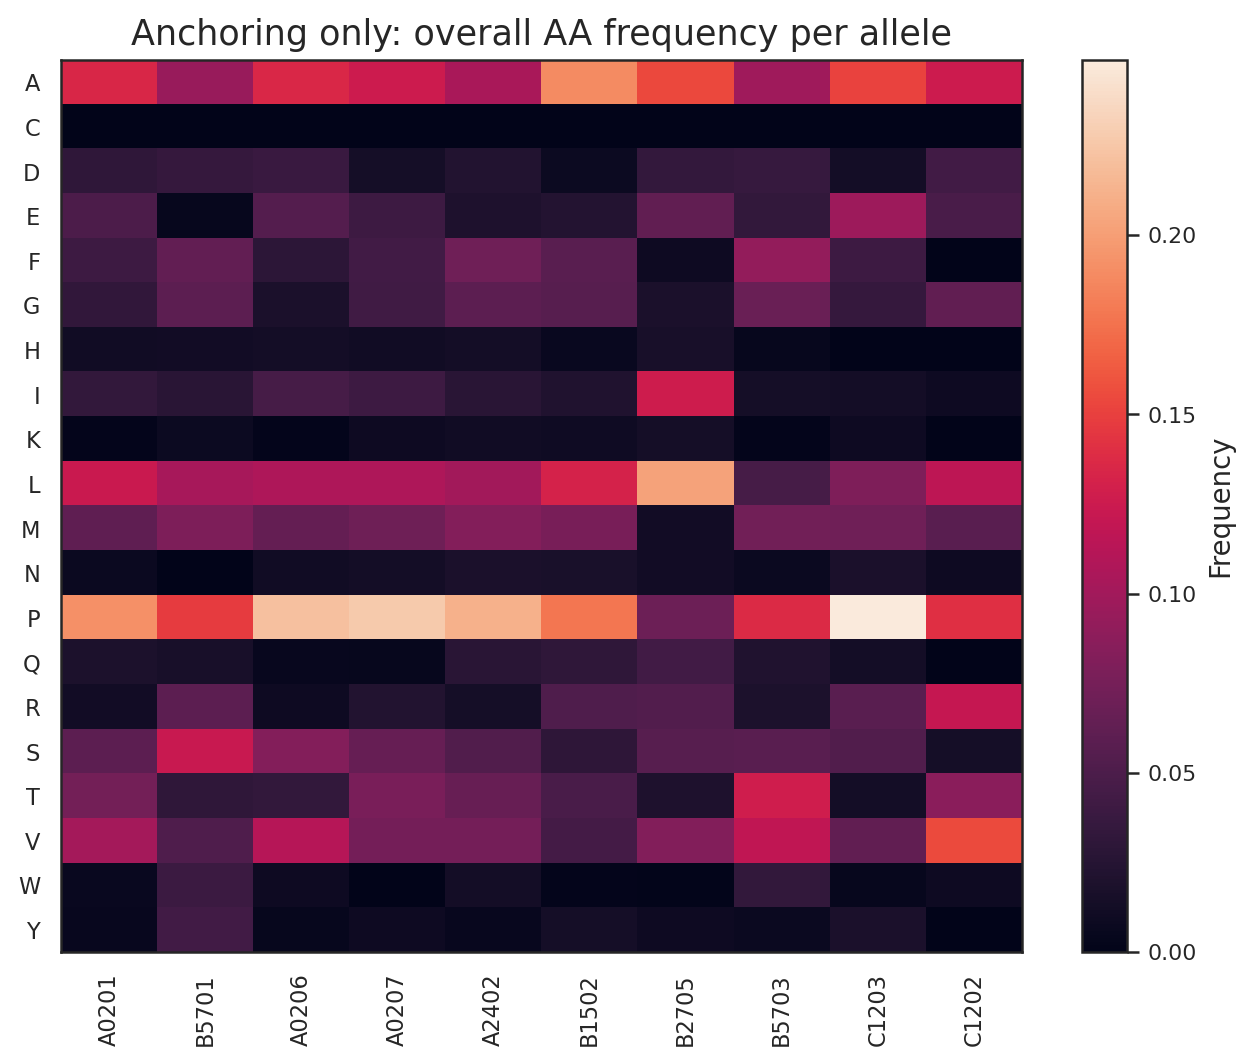

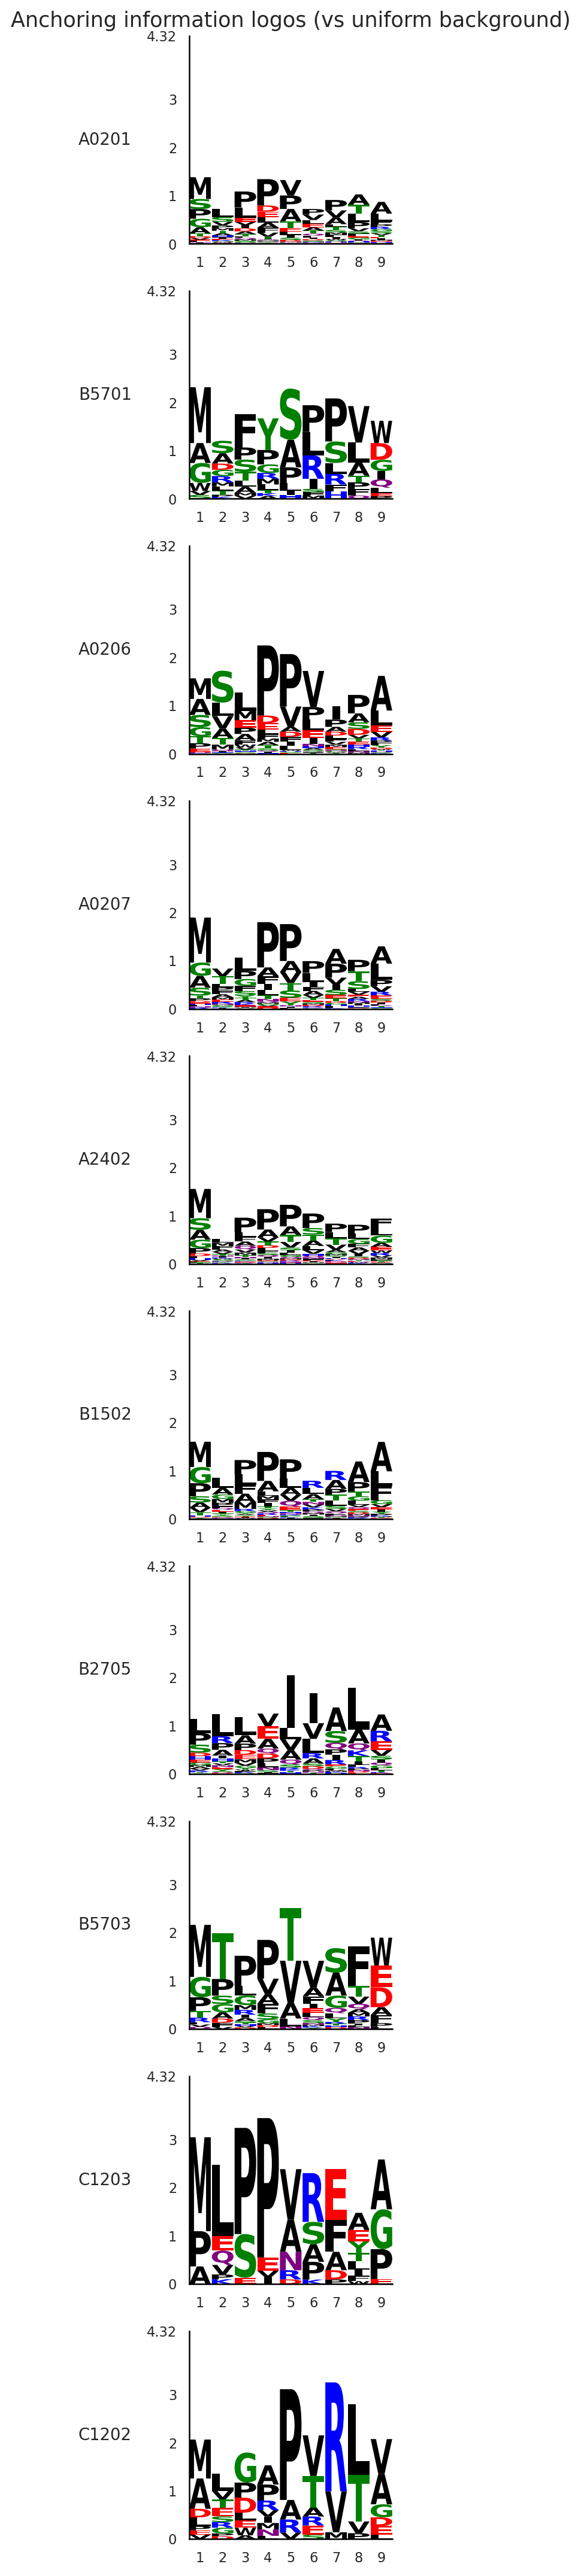

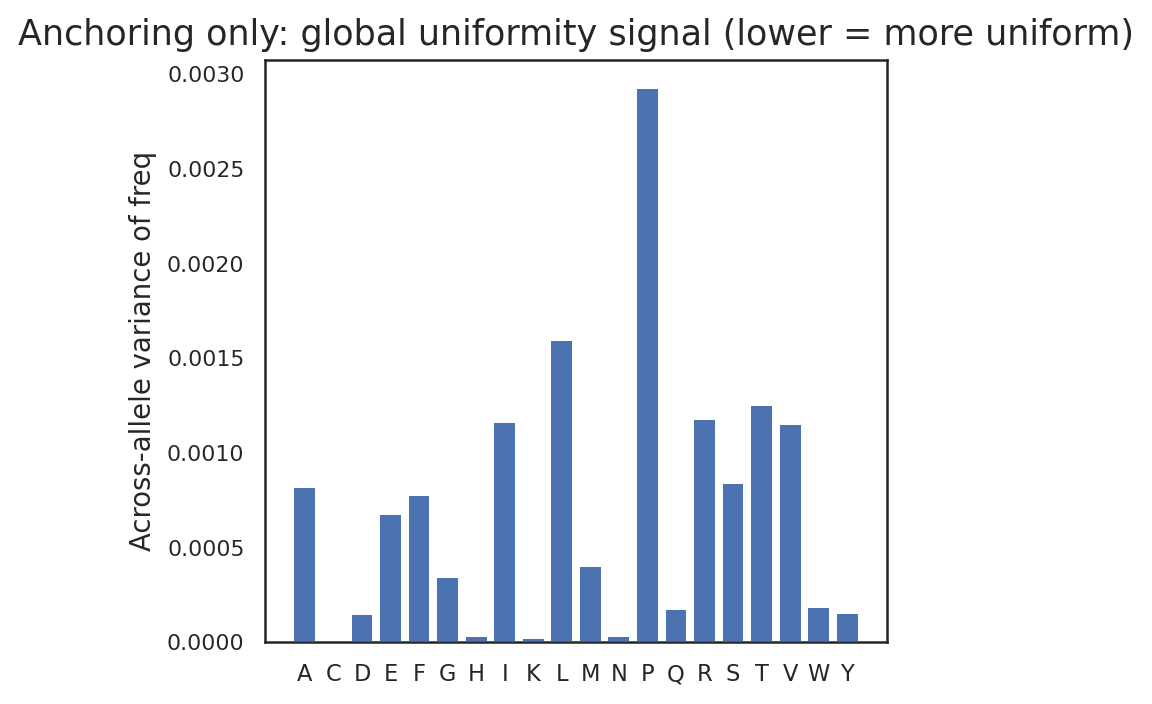

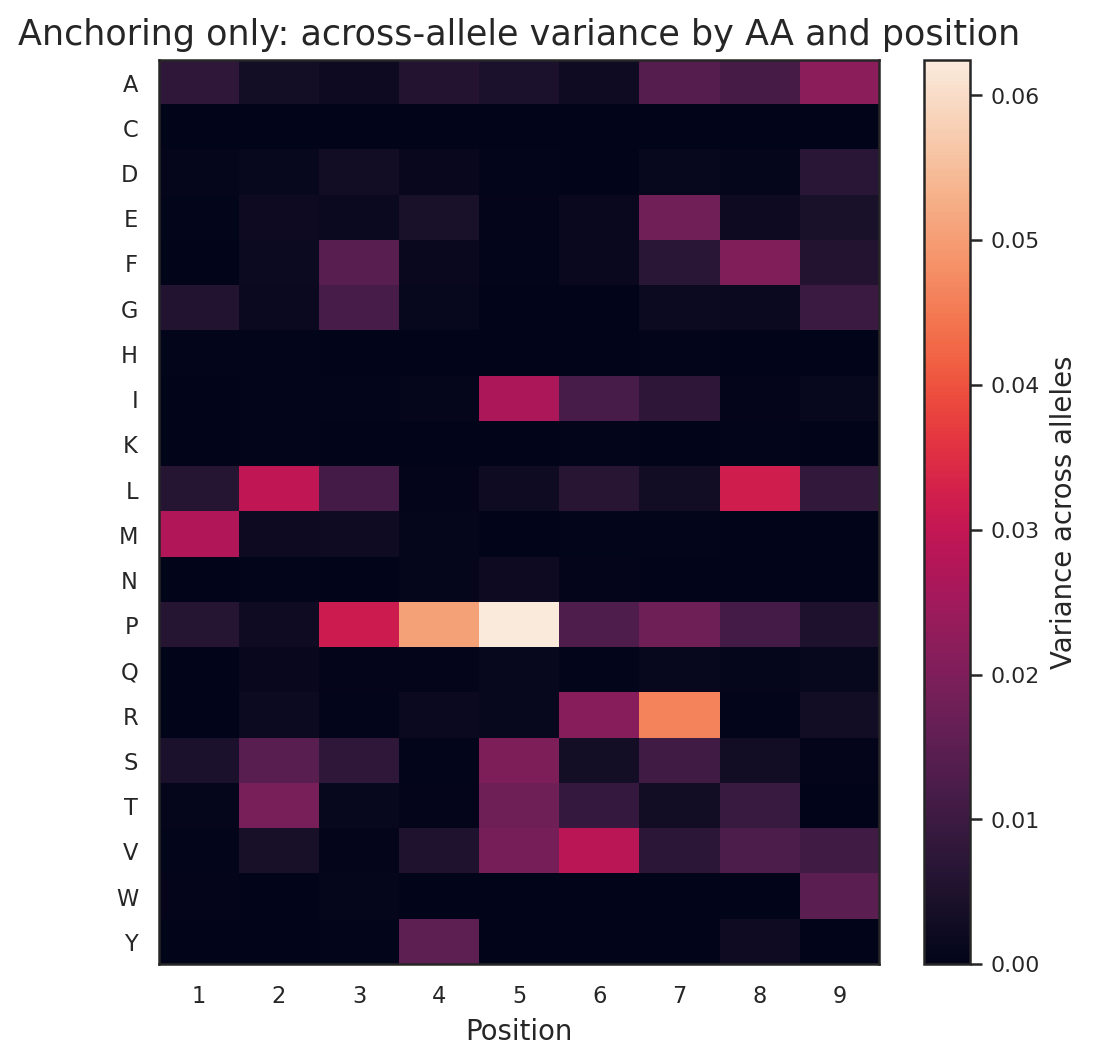

In [12]:

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
aa2i = {a:i for i,a in enumerate(amino_acids)}
alleles = ['A0201','B5701','A0206','A0207','A2402','B1502','B2705','B5703','C1203','C1202']  # de-dup if needed
L = 9                       # peptide length analyzed
plddt_thr = 0.6             # filter for Anchoring set
BITS = 4.321928094          # log2(20)

# Font sizes
fs_title = 14
fs_label = 11
fs_tick = 9

# ---------- Helpers ----------
def clean_seqs(df, L=9, seq_col="epitope"):
    """Uppercase, drop NaN, filter to length L and valid alphabet."""
    if df is None or df.empty:
        return pd.DataFrame(columns=[seq_col, "hla_allele"])
    out = df[[seq_col, "hla_allele"]].dropna().copy()
    out[seq_col] = out[seq_col].str.upper().str.replace(r"[^A-Z]", "", regex=True)
    mask = out[seq_col].str.len() == L
    mask &= out[seq_col].apply(lambda s: all(c in aa2i for c in s))
    return out.loc[mask].copy()

def build_pwm_by_allele(df, L=9, seq_col="epitope", pseudocount=1e-6):
    """Return {allele: Lx20 probability}."""
    d = {}
    for allele, sub in df.groupby("hla_allele", sort=False):
        counts = np.full((L, 20), pseudocount, dtype=float)
        nseq = 0
        for s in sub[seq_col]:
            if len(s) != L: 
                continue
            for i, aa in enumerate(s):
                counts[i, aa2i[aa]] += 1
            nseq += 1
        if nseq == 0:
            continue
        probs = counts / counts.sum(axis=1, keepdims=True)
        d[allele] = probs
    return d

def to_df(mat):
    return pd.DataFrame(mat, columns=amino_acids)

# ---------- Data subset: Anchoring only ----------
anch = results_meta.loc[results_meta["plddt"] > plddt_thr, ["epitope","hla_allele"]].copy()
anch = clean_seqs(anch, L=L, seq_col="epitope")

# Keep only alleles we care about and present
alleles_present = [a for a in alleles if a in set(anch["hla_allele"])]
anch = anch[anch["hla_allele"].isin(alleles_present)].copy()

# ---------- 1) Global AA frequency per allele ----------
rows = []
for allele, sub in anch.groupby("hla_allele", sort=False):
    counts = {aa:0 for aa in amino_acids}
    total = 0
    for s in sub["epitope"]:
        for aa in s:
            counts[aa] += 1
            total += 1
    if total == 0:
        continue
    for aa in amino_acids:
        rows.append(dict(hla_allele=allele, aa=aa, count=counts[aa], total=total, freq=counts[aa]/total))
freq_global = pd.DataFrame(rows)

# ---------- 2) Position-specific AA frequency per allele ----------
rows = []
for allele, sub in anch.groupby("hla_allele", sort=False):
    pos_counts = np.zeros((L, 20), dtype=int)
    totals = np.zeros(L, dtype=int)
    for s in sub["epitope"]:
        for i, aa in enumerate(s):
            pos_counts[i, aa2i[aa]] += 1
            totals[i] += 1
    for i in range(L):
        t = totals[i]
        if t == 0:
            continue
        for j, aa in enumerate(amino_acids):
            rows.append(dict(hla_allele=allele, pos=i+1, aa=aa,
                             count=pos_counts[i, j], total=t, freq=pos_counts[i, j]/t))
freq_positional = pd.DataFrame(rows)

# ---------- 3) Bias quantification: across-allele uniformity ----------
# Idea: if a residue's frequency is nearly identical across alleles, it may be a design bias rather than biology.
# We compute across-allele variance and coefficient of variation (CV) per AA globally and per position.

# 3a) Global across-allele variance
glob_pivot = freq_global.pivot(index="aa", columns="hla_allele", values="freq").reindex(index=amino_acids)
glob_var = glob_pivot.var(axis=1, ddof=1).rename("var_across_alleles")
glob_mean = glob_pivot.mean(axis=1).rename("mean_across_alleles")
glob_cv = (glob_pivot.std(axis=1, ddof=1) / (glob_mean.replace(0, np.nan))).rename("cv_across_alleles")
bias_global = pd.concat([glob_mean, glob_var, glob_cv], axis=1)

# 3b) Positional across-allele variance (per AA, per position)
pos_pivot = freq_positional.pivot_table(index=["aa","pos"], columns="hla_allele", values="freq")
pos_var = pos_pivot.var(axis=1, ddof=1).rename("var_across_alleles")
pos_mean = pos_pivot.mean(axis=1).rename("mean_across_alleles")
pos_cv = (pos_pivot.std(axis=1, ddof=1) / (pos_mean.replace(0, np.nan))).rename("cv_across_alleles")
bias_positional = pd.concat([pos_mean, pos_var, pos_cv], axis=1).reset_index()

# ---------- 4) Plots ----------
# A) Global AA frequency heatmap (alleles as columns)
fig, ax = plt.subplots(figsize=(1.2 + 0.6*len(alleles_present), 6))
mat = glob_pivot[alleles_present].values
im = ax.imshow(mat, aspect="auto", interpolation="nearest")
ax.set_yticks(range(len(amino_acids))); ax.set_yticklabels(amino_acids, fontsize=fs_tick)
ax.set_xticks(range(len(alleles_present))); ax.set_xticklabels(alleles_present, rotation=90, fontsize=fs_tick)
ax.set_title("Anchoring only: overall AA frequency per allele", fontsize=fs_title)
cbar = plt.colorbar(im, ax=ax); cbar.set_label("Frequency", fontsize=fs_label)
plt.tight_layout()

# B) Per-position logo grid for each allele (Anchoring only)
n_rows = len(alleles_present); n_cols = 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.4 * n_rows), squeeze=False)

# Build PWMs once
pwm_anchor = build_pwm_by_allele(anch, L=L, seq_col="epitope", pseudocount=1e-6)

for r, allele in enumerate(alleles_present):
    ax = axes[r, 0]
    pwm = pwm_anchor.get(allele, None)
    if pwm is None:
        ax.axis("off"); continue
    freq_df = to_df(pwm)
    info_df = logomaker.transform_matrix(
        freq_df, from_type="probability", to_type="information", background=[1/20]*20
    )
    logo = logomaker.Logo(info_df, ax=ax, color_scheme="chemistry")
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left','bottom'], visible=True)
    ax.set_xticks(range(L)); ax.set_xticklabels([str(i+1) for i in range(L)], fontsize=fs_tick)
    ax.set_ylim(0, BITS)
    ax.set_yticks([0,1,2,3,round(BITS,2)]); ax.set_yticklabels(["0","1","2","3","4.32"], fontsize=fs_tick)
    ax.set_ylabel(allele, rotation=0, fontsize=fs_label, labelpad=28, va="center")
axes[0,0].set_title("Anchoring information logos (vs uniform background)", fontsize=fs_title)
plt.tight_layout()

# C) Bias heatmaps: across-allele variance
# Global variance by AA
fig, ax = plt.subplots(figsize=(4.5, 4.0))
ax.bar(range(len(amino_acids)), bias_global["var_across_alleles"].reindex(amino_acids).values)
ax.set_xticks(range(len(amino_acids))); ax.set_xticklabels(amino_acids, fontsize=fs_tick)
ax.set_ylabel("Across-allele variance of freq", fontsize=fs_label)
ax.set_title("Anchoring only: global uniformity signal (lower = more uniform)", fontsize=fs_title)
plt.tight_layout()

# Positional variance heatmap (AA x position)
# Lower variance cells suggest potential design bias at that AA-position across alleles.
pos_var_mat = (
    bias_positional
    .pivot(index="aa", columns="pos", values="var_across_alleles")
    .reindex(index=amino_acids)
    .reindex(columns=range(1, L+1))
)
fig, ax = plt.subplots(figsize=(1.2 + 0.5*L, 6))
im = ax.imshow(pos_var_mat.values, aspect="auto", interpolation="nearest")
ax.set_yticks(range(len(amino_acids))); ax.set_yticklabels(amino_acids, fontsize=fs_tick)
ax.set_xticks(range(L)); ax.set_xticklabels(range(1, L+1), fontsize=fs_tick)
ax.set_xlabel("Position", fontsize=fs_label)
ax.set_title("Anchoring only: across-allele variance by AA and position", fontsize=fs_title)
cbar = plt.colorbar(im, ax=ax); cbar.set_label("Variance across alleles", fontsize=fs_label)
plt.tight_layout()

# ---------- 5) Quick textual summaries ----------
# Allele sizes (for context; very small N can create apparent uniformity)
allele_sizes = anch.groupby("hla_allele")["epitope"].size().rename("n_seqs").sort_values(ascending=False)
print("Anchoring allele sizes:\n", allele_sizes.to_string(), "\n")

# Globally most uniform AAs across alleles (smallest variance)
print("Global most-uniform AAs (potential design bias), top 5:")
print(bias_global.sort_values("var_across_alleles").head(5).to_string(), "\n")

# Per-position most uniform cells
print("Per-position most-uniform AA positions (top 10):")
print(
    bias_positional.sort_values("var_across_alleles")
    .loc[:, ["aa","pos","mean_across_alleles","var_across_alleles","cv_across_alleles"]]
    .head(10)
    .to_string()
)


In [17]:
def pct_matrix_from_df(df, L=9, seq_col="epitope"):
    """Return a 20xL DataFrame of percentages (% of sequences) for each AA at each position."""
    counts = np.zeros((20, L), dtype=int)
    totals = np.zeros(L, dtype=int)

    for s in df[seq_col]:
        if len(s) != L:
            continue
        for i, aa in enumerate(s):
            if aa in aa2i:
                counts[aa2i[aa], i] += 1
                totals[i] += 1

    with np.errstate(divide="ignore", invalid="ignore"):
        pct = counts / np.maximum(totals, 1)  # avoid div by zero
    pct_df = pd.DataFrame(pct, index=amino_acids, columns=[f"{i+1}" for i in range(L)])
    return pct_df

# 1) Overall percentage matrix across all alleles
pct_overall = pct_matrix_from_df(anch, L=L)
print(pct_overall.round(4))

# 2) Per-allele percentage matrices
pct_by_allele = {
    allele: pct_matrix_from_df(sub, L=L)
    for allele, sub in anch.groupby("hla_allele", sort=False)
}


        1       2       3       4       5       6       7       8       9
A  0.1066  0.0874  0.0796  0.1084  0.1578  0.0988  0.1377  0.1793  0.2411
C  0.0000  0.0005  0.0000  0.0000  0.0005  0.0000  0.0000  0.0000  0.0000
D  0.0265  0.0133  0.0339  0.0622  0.0188  0.0215  0.0142  0.0192  0.0252
E  0.0142  0.0265  0.0499  0.0544  0.0371  0.0526  0.0192  0.0311  0.0590
F  0.0078  0.0608  0.0718  0.0590  0.0078  0.0375  0.0403  0.0586  0.1157
G  0.1308  0.0384  0.0261  0.0091  0.0105  0.0073  0.0306  0.0608  0.0814
H  0.0137  0.0206  0.0037  0.0041  0.0059  0.0151  0.0142  0.0105  0.0087
I  0.0023  0.0325  0.0352  0.0270  0.0489  0.0499  0.0453  0.0279  0.0247
K  0.0027  0.0133  0.0046  0.0046  0.0055  0.0119  0.0078  0.0082  0.0018
L  0.0183  0.2049  0.1725  0.0654  0.0622  0.1153  0.0938  0.1491  0.1715
M  0.3486  0.0897  0.0540  0.0242  0.0110  0.0183  0.0375  0.0160  0.0224
N  0.0041  0.0165  0.0119  0.0119  0.0105  0.0256  0.0114  0.0110  0.0078
P  0.1212  0.0618  0.2832  0.4062  0.2

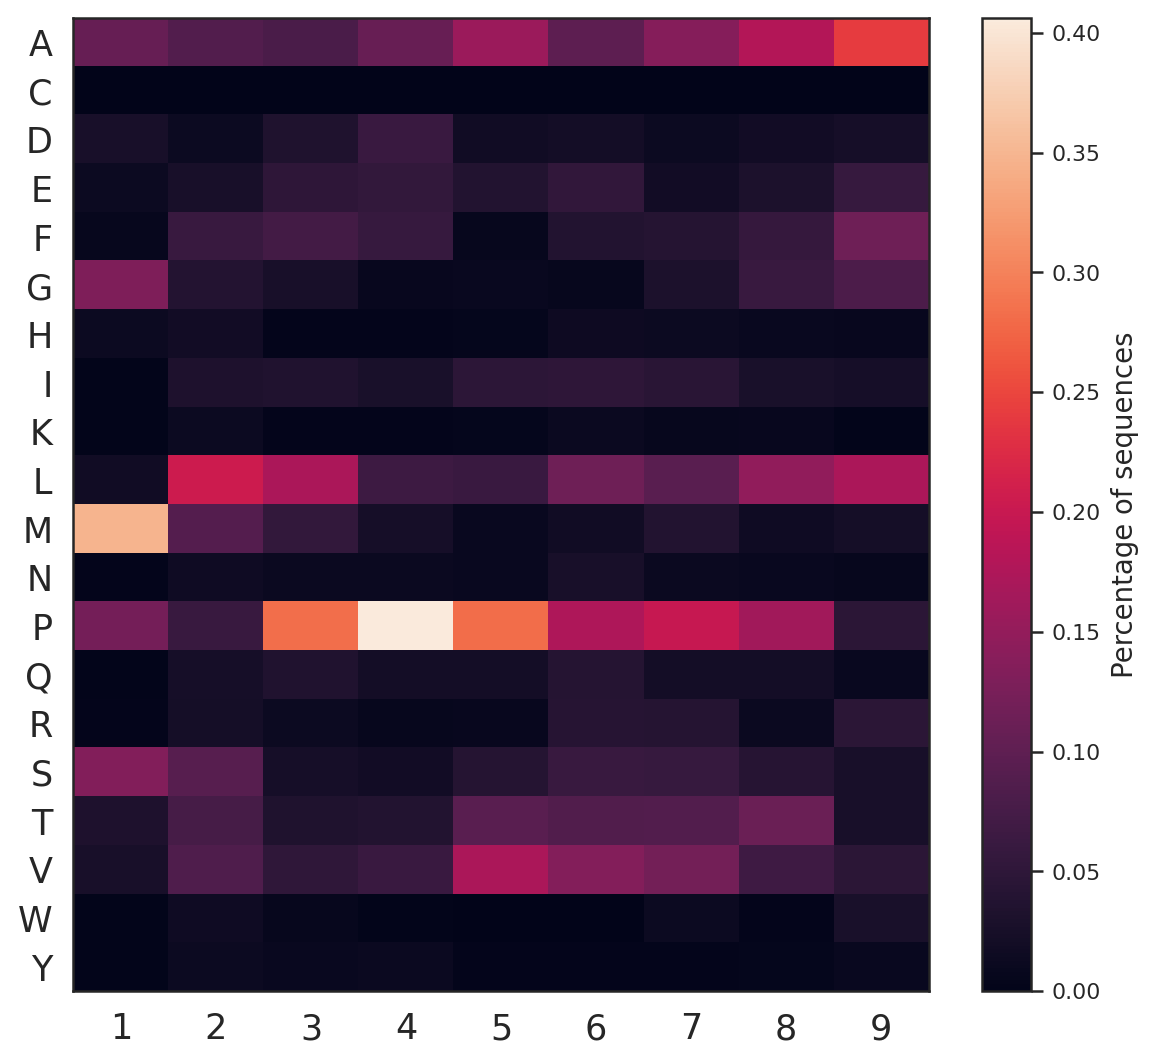

In [42]:
#pct_overall plot matrix
fig, ax = plt.subplots(figsize=(1.2 + 0.6 * L, 6))
im = ax.imshow(pct_overall.values, aspect="auto", interpolation="nearest")
ax.set_yticks(range(len(amino_acids)))
ax.set_yticklabels(amino_acids, fontsize=fs_tick)
ax.set_xticks(range(L))
ax.set_xticklabels([str(i + 1) for i in range(L)], fontsize=fs_tick)
# ax.set_title("Anchoring only: overall AA percentage per position", fontsize=fs_title)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Percentage of sequences", fontsize=fs_label)
plt.tight_layout()
# Per-allele percentage matrices
#save   
plt.savefig('../figures/bias_overall_percentage_matrix.pdf', bbox_inches='tight')


In [36]:
# ---------------- Config ----------------
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
alleles_in  = ['A0201','A0206','A0207','A2402','B5701', 'B1502','B2705','B5703','C1203']
alleles     = list(dict.fromkeys(alleles_in))  # de-dup, keep order
L           = 9
plddt_thr   = 0.5
BITS        = 2.0           # cap at ±2 bits (display)
N_ROWS, N_COLS = 3, 3
SAVE_DIR    = None

fs_tick, fs_title, fs_panel = 8, 14, 10

aa2i = {a:i for i,a in enumerate(amino_acids)}
eps = 1e-9

# ---------------- Helpers ----------------
def _clean_seq(s):
    import re
    s = str(s).upper()
    return re.sub(r'[^A-Z]', '', s)

def clean_anch(df, L=9, seq_col="epitope", thr=0.7):
    sub = df.loc[df["plddt"] > thr, [seq_col, "hla_allele"]].dropna().copy()
    sub[seq_col] = sub[seq_col].map(_clean_seq)
    sub = sub[sub[seq_col].str.len() == L]
    sub = sub[sub[seq_col].apply(lambda s: all(c in aa2i for c in s))]
    return sub

def build_pwm_by_allele(df, L=9, seq_col="epitope", pseudocount=1e-6):
    import numpy as np
    out = {}
    for allele, sub in df.groupby("hla_allele", sort=False):
        counts = np.full((L, 20), pseudocount, dtype=float)
        n = 0
        for s in sub[seq_col]:
            for i, aa in enumerate(s):
                counts[i, aa2i[aa]] += 1.0
            n += 1
        if n > 0:
            out[allele] = counts / counts.sum(axis=1, keepdims=True)
    return out

def to_df(mat):
    import pandas as pd
    return pd.DataFrame(mat, columns=amino_acids)

def normalize_rows(m, eps=1e-9):
    import numpy as np
    m = np.asarray(m, dtype=float) + eps
    return m / m.sum(axis=1, keepdims=True)

def info_vs_background(P, Q_pos, eps=1e-9, clip_neg=True):
    """
    Lx20 matrix of P * log2(P/Q) against positional background Q_pos.
    clip_neg=True zeros negative components (keeps logos clean).
    """
    import numpy as np
    Pn = normalize_rows(P, eps)
    Qn = normalize_rows(Q_pos, eps)
    M  = Pn * np.log2(Pn / np.clip(Qn, eps, None))
    if clip_neg:
        M[M < 0] = 0.0
    return M

# ---------------- Data prep ----------------
anch = clean_anch(results_meta, L=L, seq_col="epitope", thr=plddt_thr)
present = [a for a in alleles if a in set(anch["hla_allele"])]
pwm_anchor = build_pwm_by_allele(anch, L=L, seq_col="epitope", pseudocount=1e-6)

counts = np.zeros((L, 20), dtype=float)
for s in anch["epitope"]:
    for i, aa in enumerate(s):
        counts[i, aa2i[aa]] += 1.0
Q_pos = counts + eps
Q_pos = Q_pos / Q_pos.sum(axis=1, keepdims=True)

# ---------------- Plot: grid with pagination ----------------
per_page = N_ROWS * N_COLS
pages = [present[i:i+per_page] for i in range(0, len(present), per_page)]

if SAVE_DIR:
    os.makedirs(SAVE_DIR, exist_ok=True)

import logomaker

aa_color_scheme = {
    'A':'black', 'V':'black', 'L':'black', 'I':'black',
    'P':'black', 'W':'black', 'F':'black', 'M':'black',
    'G':'green', 'S':'green', 'T':'green', 'Y':'green',
    'C':'green', 'Q':'green', 'N':'green',
    'D':'red', 'E':'red',
    'K':'blue', 'R':'blue', 'H':'blue'
}

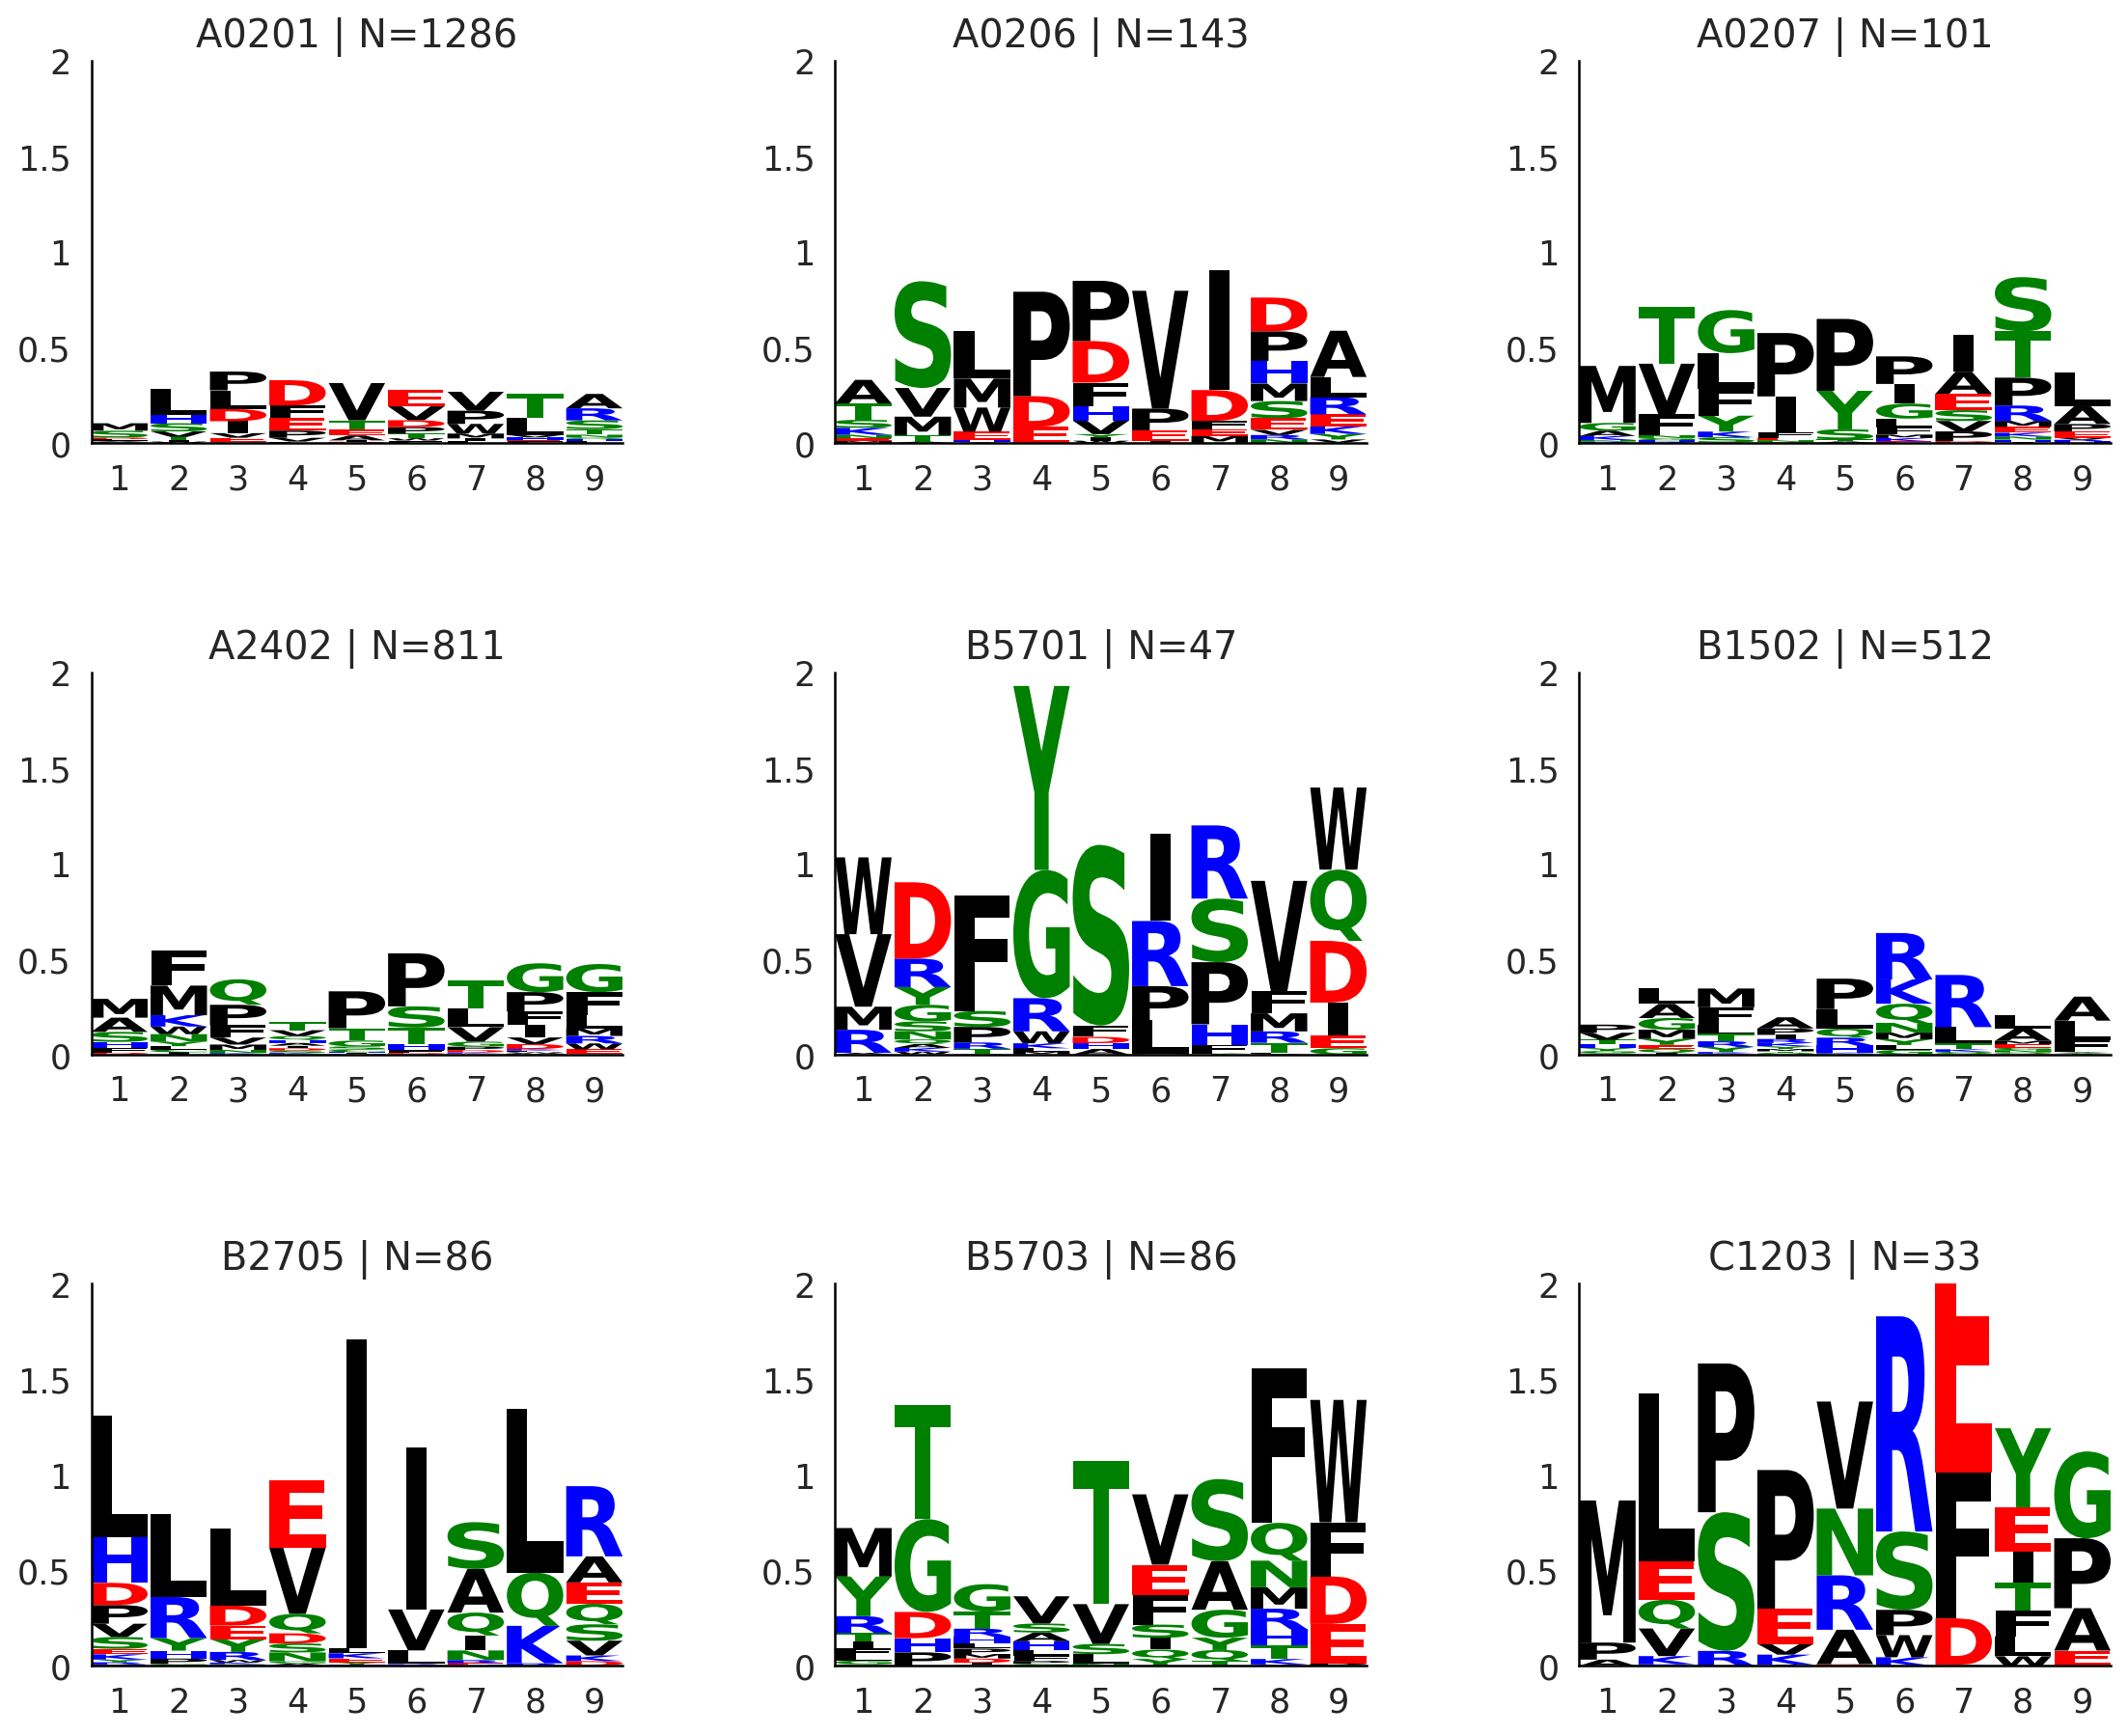

In [38]:
# --- Font sizes ---
fs_tick  = 14   # bigger ticks
fs_panel = 16   # panel titles
fs_title = 18   # overall title

for page_idx, page_alleles in enumerate(pages, start=1):
    fig, axes = plt.subplots(
        N_ROWS, N_COLS,
        figsize=(5*N_COLS, 4*N_ROWS),  # larger panels
        squeeze=False
    )
    ax_flat = axes.ravel()

    for ax, allele in zip(ax_flat, page_alleles):
        P = pwm_anchor.get(allele)
        if P is None:
            ax.axis("off"); continue

        # Info vs background (negatives clipped)
        M = info_vs_background(P, Q_pos, eps=eps, clip_neg=True)
        M = np.clip(M, 0.0, BITS)

        logo_df = to_df(M)
        ax.clear()
        logo = logomaker.Logo(logo_df, ax=ax, color_scheme=aa_color_scheme)
        logo.style_spines(visible=False)
        logo.style_spines(spines=['left','bottom'], visible=True)

        num_epitopes = anch[anch["hla_allele"] == allele].shape[0]

        ax.set_ylim(0, BITS)
        ax.set_yticks([0, 0.5, 1, 1.5, 2])
        ax.set_yticklabels(["0","0.5","1","1.5","2"], fontsize=fs_tick)
        ax.set_xticks(range(L))
        ax.set_xticklabels([str(i+1) for i in range(L)], fontsize=fs_tick)
        ax.set_title(f'{allele} | N={num_epitopes}', fontsize=fs_panel)

    for ax in ax_flat[len(page_alleles):]:
        ax.axis("off")

    # More separation between plots
    plt.subplots_adjust(wspace=0.4, hspace=0.6)

    # Optional global title
    # fig.suptitle("Anchoring logos vs positional background", fontsize=fs_title, y=1.02)

    # Save & show
    plt.savefig(f'../figures/anchoring_logos_page{page_idx}.pdf', dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
break

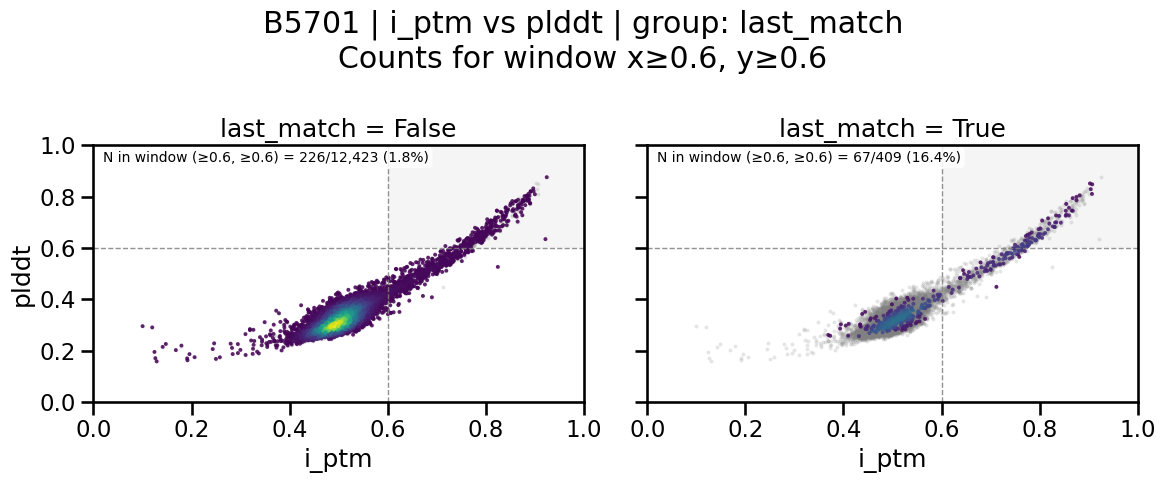

In [ ]:
# Example usage:
counts = plot_kde_density(
    results,
    pos2_set={"A", "S", "T"},
    last_set={"W", "Y", "F"},
    alleles=['B5701'],
    match_types=["last_match"],
    show_grey=True,
    show_window=True,
    thr=0.6
)

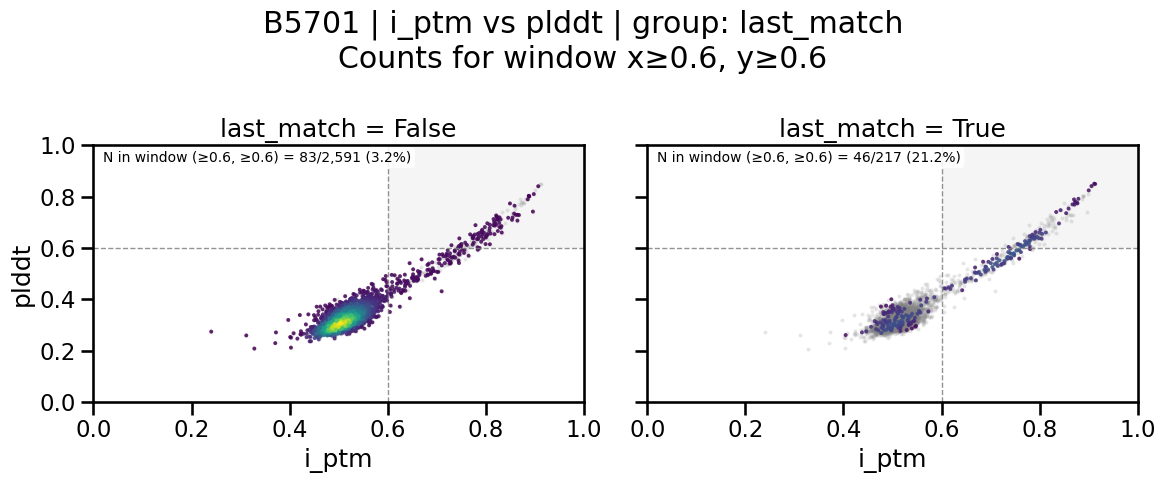

In [ ]:
# Example usage:
counts = plot_kde_density(
    results_meta,
    pos2_set={"A", "S", "T"},
    last_set={"W", "Y", "F"},
    alleles=['B5701'],
    match_types=["last_match"],
    show_grey=True,
    show_window=True,
    thr=0.6
)